In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
df.shape

(1338, 7)

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

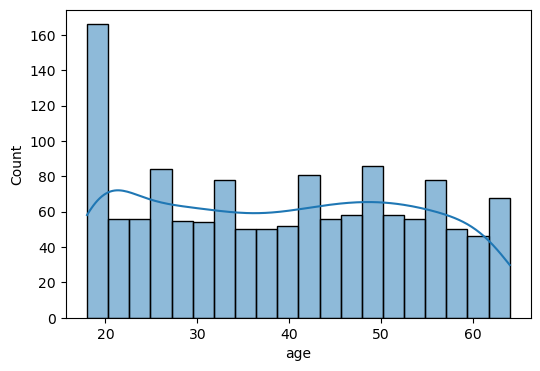

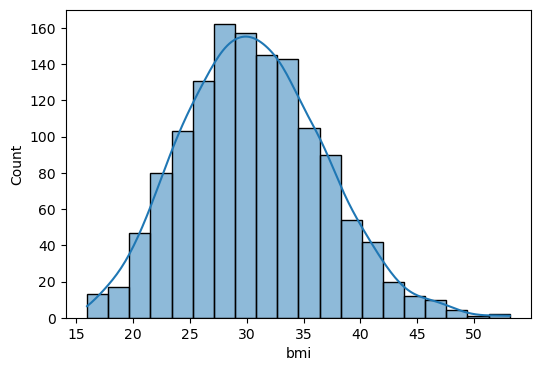

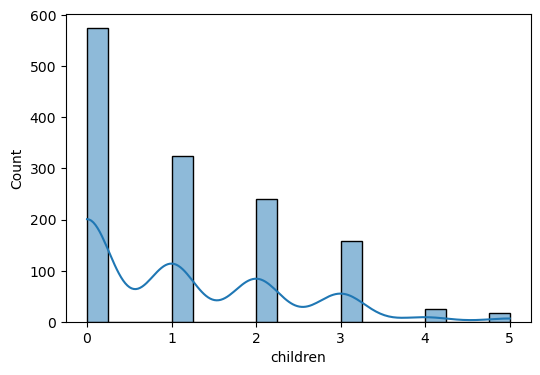

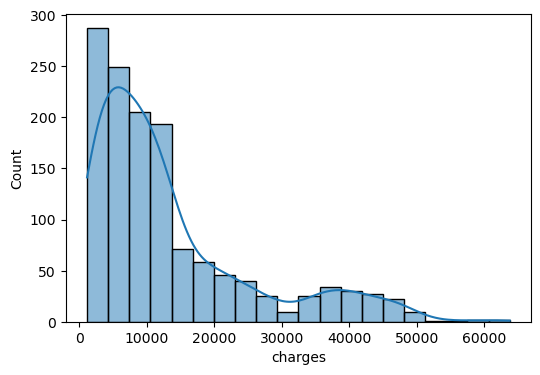

In [9]:
numeric_columns = ['age', 'bmi', 'children','charges']

for col in numeric_columns: 
    plt.figure(figsize= (6,4))
    sns.histplot(df[col] , kde = True , bins= 20)

<Axes: xlabel='children', ylabel='count'>

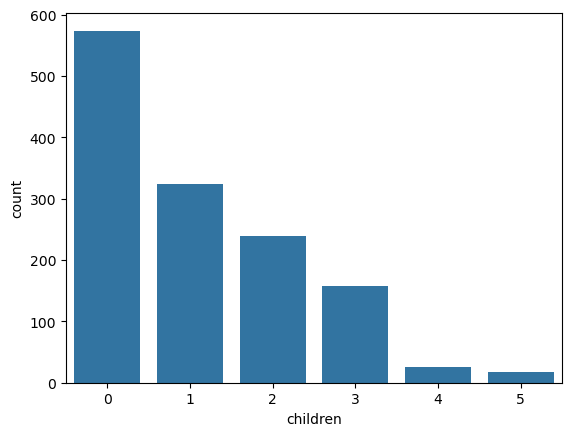

In [10]:
sns.countplot(x = df['children'])

<Axes: xlabel='smoker', ylabel='count'>

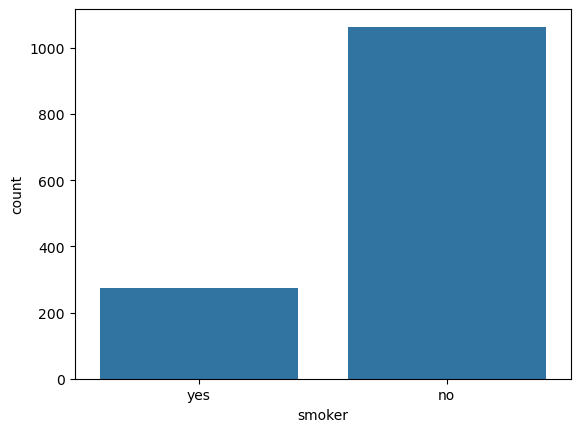

In [11]:
sns.countplot(x = df['smoker'])

<Axes: xlabel='sex', ylabel='count'>

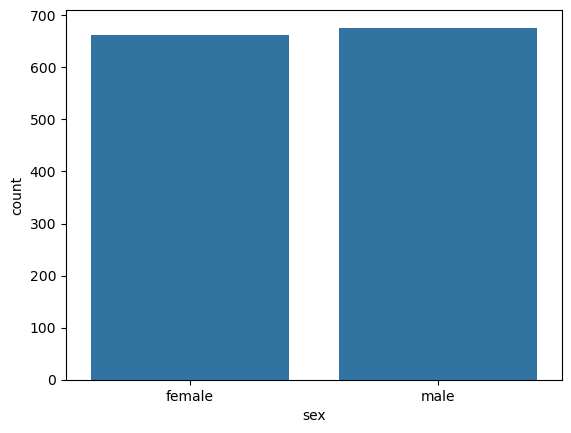

In [12]:
sns.countplot(x = df['sex'])

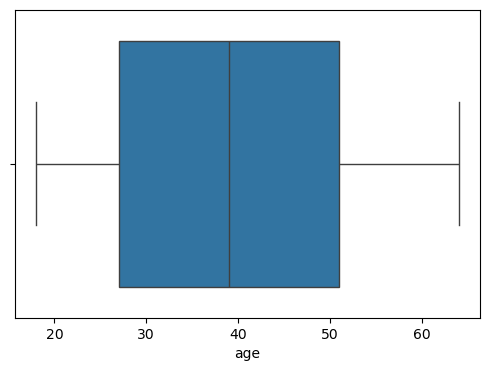

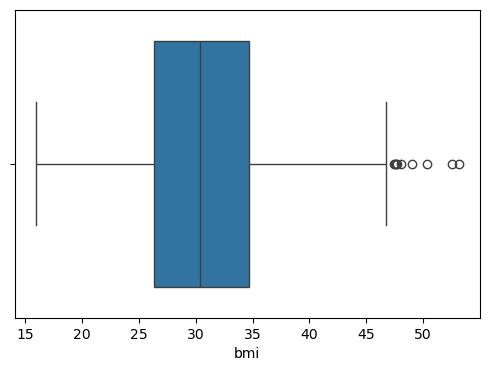

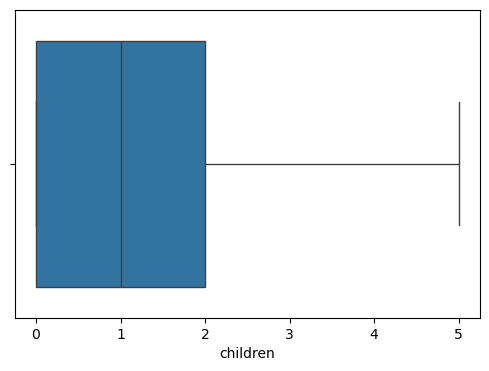

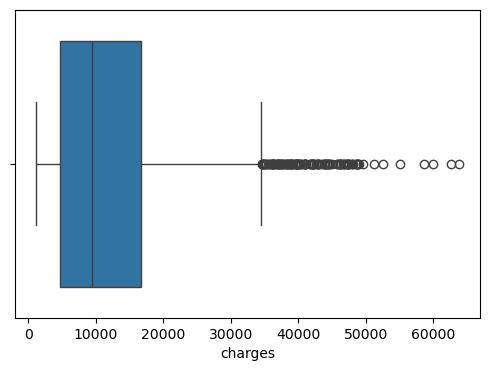

In [13]:
for col in numeric_columns:
    plt.figure(figsize= (6,4))
    sns.boxplot(x = df[col])

<Axes: >

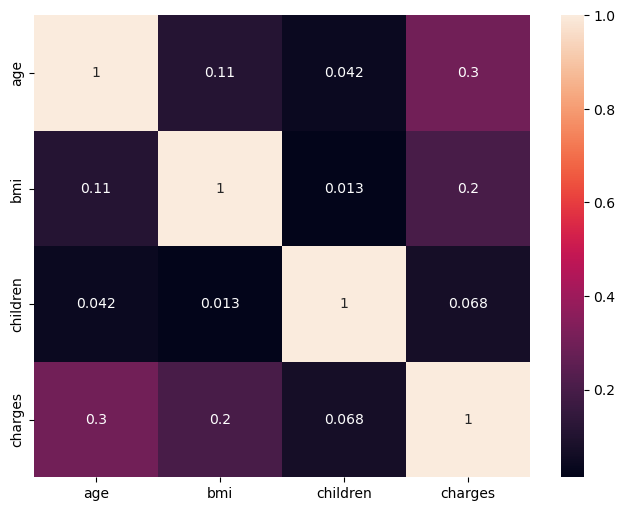

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

# Data Cleaning and preprocessing

In [15]:
df_cleaned = df.copy()

In [16]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [17]:
df_cleaned.shape

(1338, 7)

In [18]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [19]:
df_cleaned.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [20]:
df_cleaned['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [21]:
df_cleaned['sex'] = df_cleaned['sex'].map({"male" : 0,"female" : 1})

In [22]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [23]:
df_cleaned['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [24]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({"no" : 0,"yes" : 1})
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [25]:
df_cleaned.rename(columns= {
    'sex' : 'is_female', 
    'smoker' : 'is_smoker' 
                    } , inplace = True)

df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [26]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [27]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [28]:
df_cleaned = pd.get_dummies(df_cleaned , columns = ['region'])

In [29]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,0,33.770,1,0,1725.55230,False,False,True,False
2,28,0,33.000,3,0,4449.46200,False,False,True,False
3,33,0,22.705,0,0,21984.47061,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False


In [30]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest'],
      dtype='object')

In [31]:
df_cleaned = df_cleaned.astype(int)

In [32]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,0,1
1,18,0,33,1,0,1725,0,0,1,0
2,28,0,33,3,0,4449,0,0,1,0
3,33,0,22,0,0,21984,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0
1334,18,1,31,0,0,2205,1,0,0,0
1335,18,1,36,0,0,1629,0,0,1,0
1336,21,1,25,0,0,2007,0,0,0,1


# Feature Engineering and Extraction

<Axes: xlabel='bmi', ylabel='Count'>

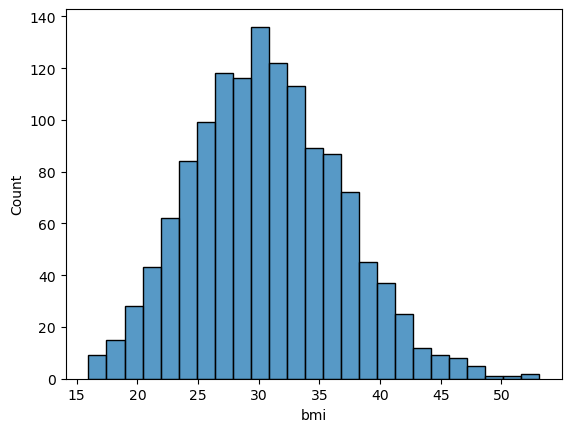

In [33]:
sns.histplot(df['bmi'])

In [34]:
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'],
    bins=[0, 18.5, 24.9, 29.9, float('inf')],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

In [35]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,0,1,Overweight
1,18,0,33,1,0,1725,0,0,1,0,Obese
2,28,0,33,3,0,4449,0,0,1,0,Obese
3,33,0,22,0,0,21984,0,1,0,0,Normal
4,32,0,28,0,0,3866,0,1,0,0,Overweight
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0,Obese
1334,18,1,31,0,0,2205,1,0,0,0,Obese
1335,18,1,36,0,0,1629,0,0,1,0,Obese
1336,21,1,25,0,0,2007,0,0,0,1,Overweight


In [36]:
df_cleaned = pd.get_dummies(df_cleaned,columns= ['bmi_category'])

In [37]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,0,1,False,False,True,False
1,18,0,33,1,0,1725,0,0,1,0,False,False,False,True
2,28,0,33,3,0,4449,0,0,1,0,False,False,False,True
3,33,0,22,0,0,21984,0,1,0,0,False,True,False,False
4,32,0,28,0,0,3866,0,1,0,0,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0,False,False,False,True
1334,18,1,31,0,0,2205,1,0,0,0,False,False,False,True
1335,18,1,36,0,0,1629,0,0,1,0,False,False,False,True
1336,21,1,25,0,0,2007,0,0,0,1,False,False,True,False


In [38]:
df_cleaned = df_cleaned.astype(int)
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,0,1,0,0,1,0
1,18,0,33,1,0,1725,0,0,1,0,0,0,0,1
2,28,0,33,3,0,4449,0,0,1,0,0,0,0,1
3,33,0,22,0,0,21984,0,1,0,0,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0,0,0,1,0


In [39]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_Underweight', 'bmi_category_Normal',
       'bmi_category_Overweight', 'bmi_category_Obese'],
      dtype='object')

In [40]:
from sklearn.preprocessing import StandardScaler
cols = ['age','bmi','children']
scaler = StandardScaler()

df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [41]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.438764,1,-0.518122,-0.908614,1,16884,0,0,0,1,0,0,1,0
1,-1.509965,0,0.462657,-0.078767,0,1725,0,0,1,0,0,0,0,1
2,-0.797954,0,0.462657,1.580926,0,4449,0,0,1,0,0,0,0,1
3,-0.441948,0,-1.335438,-0.908614,0,21984,0,1,0,0,0,1,0,0
4,-0.513149,0,-0.354659,-0.908614,0,3866,0,1,0,0,0,0,1,0


In [42]:
from scipy.stats import pearsonr

# ----------------------------------
# Pearson Correlation Calculation
# ----------------------------------

# List of features to check against target
selected_features = [
    'age', 'bmi', 'children', 'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)


,Feature,Pearson Correlation
4,is_smoker,0.787251
0,age,0.299009
10,bmi_category_Obese,0.199533
1,bmi,0.196188
6,region_southeast,0.073981
2,children,0.067999
5,region_northwest,-0.039905
7,region_southwest,-0.043210
3,is_female,-0.057293
8,bmi_category_Normal,-0.103679


In [43]:
# Categorical Data|
cat_features = [
    'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

In [44]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
is_smoker,854.020268,0.0,Reject Null (Keep Feature)
region_southeast,15.208814,0.001647,Reject Null (Keep Feature)
is_female,9.532132,0.022992,Reject Null (Keep Feature)
bmi_category_Obese,8.510101,0.036566,Reject Null (Keep Feature)
region_southwest,5.530825,0.136807,Accept Null (Drop Feature)
bmi_category_Overweight,4.620089,0.201826,Accept Null (Drop Feature)
bmi_category_Normal,3.578987,0.310661,Accept Null (Drop Feature)
region_northwest,1.226112,0.746749,Accept Null (Drop Feature)


In [45]:
final_df = df_cleaned[['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges','region_southeast','bmi_category_Obese']]

In [46]:
final_df

,age,is_female,bmi,children,is_smoker,charges,region_southeast,bmi_category_Obese
0,-1.438764,1,-0.518122,-0.908614,1,16884,0,0
1,-1.509965,0,0.462657,-0.078767,0,1725,1,1
2,-0.797954,0,0.462657,1.580926,0,4449,1,1
3,-0.441948,0,-1.335438,-0.908614,0,21984,0,0
4,-0.513149,0,-0.354659,-0.908614,0,3866,0,0
...,...,...,...,...,...,...,...,...
1333,0.768473,0,-0.027733,1.580926,0,10600,0,1
1334,-1.509965,1,0.135731,-0.908614,0,2205,0,1
1335,-1.509965,1,0.953046,-0.908614,0,1629,1,1
1336,-1.296362,1,-0.845048,-0.908614,0,2007,0,0


In [47]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [48]:
from sklearn.model_selection import train_test_split

In [49]:
x = final_df.drop('charges' , axis = 1)
y = final_df['charges']

In [50]:
y

0       16884
1        1725
2        4449
3       21984
4        3866
        ...  
1333    10600
1334     2205
1335     1629
1336     2007
1337    29141
Name: charges, Length: 1338, dtype: int64

In [51]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [52]:
from sklearn.linear_model import LinearRegression

In [53]:
model = LinearRegression()
model.fit(X_train , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [54]:
y_pred = model.predict(X_test)

In [59]:
y_pred

array([ 8.07044764e+03,  8.75451143e+03,  3.58899075e+04,  8.72069546e+03,
        2.81210589e+04,  9.96162939e+03,  2.29325786e+02,  1.67112432e+04,
        1.99023693e+03,  9.82423898e+03,  2.81414366e+04,  1.08448965e+04,
        3.89589476e+03,  3.74250616e+04,  3.95692550e+04,  3.68279154e+04,
        1.41575352e+04,  3.62134327e+04,  8.15681164e+03,  3.04896820e+04,
        3.92212710e+03,  1.15805921e+04,  4.36447172e+03,  6.15060929e+03,
        1.00998212e+04,  1.36046646e+04,  1.54796689e+04,  7.67469752e+03,
        8.69544907e+03,  4.01596861e+03,  8.05050227e+03,  1.42654312e+04,
        5.24863496e+03,  3.96050106e+03,  6.57606970e+03,  1.20467134e+04,
        1.59793277e+03,  7.58739461e+03,  3.29941987e+04,  3.32556203e+04,
        2.95110534e+03,  5.65814956e+03,  1.48625774e+04,  1.08291238e+04,
        9.24978940e+03,  1.14620351e+04,  6.05233587e+03,  3.22820430e+03,
        3.58787411e+04,  9.06756494e+03,  1.62704745e+04,  1.04877661e+03,
        1.14122853e+04,  

In [60]:
y_test

764      9095
887      5272
890     29330
1293     9301
259     33750
        ...  
109     47055
575     12222
535      6067
543     63770
846      9872
Name: charges, Length: 268, dtype: int64

In [55]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
r2

n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - ((1-r2) * (n-1) / (n-p-1))
adjusted_r2

0.7753850490518059

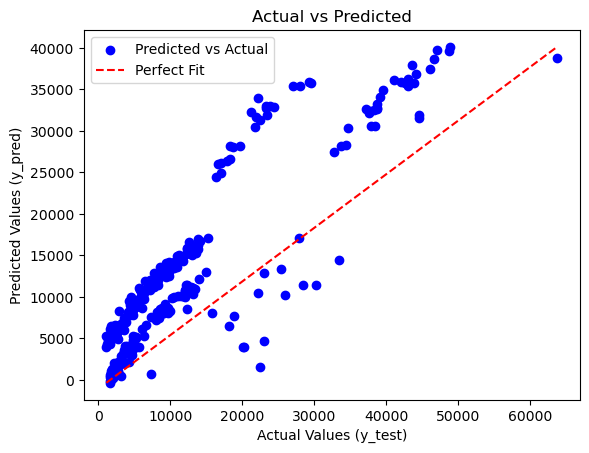

In [61]:
# import matplotlib.pyplot as plt

# Scatter plot of actual vs predicted
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()], [y_pred.min(), y_pred.max()], 
         color='red', linestyle='--', label='Perfect Fit')

plt.xlabel("Actual Values (y_test)")
plt.ylabel("Predicted Values (y_pred)")
plt.title("Actual vs Predicted")
plt.legend()
plt.show()


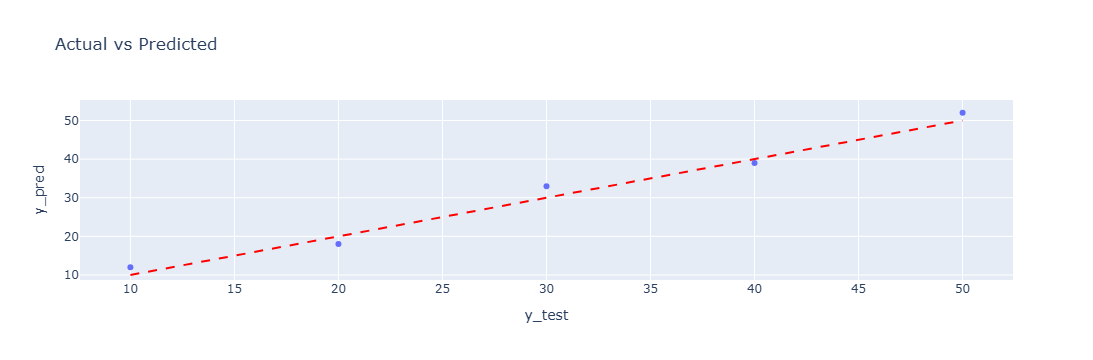

In [63]:
import plotly.express as px
import pandas as pd

# Example: y_test and y_pred arrays
# Replace with your actual data
y_test = [10, 20, 30, 40, 50]
y_pred = [12, 18, 33, 39, 52]

# Put into DataFrame
df = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})

# Scatter plot
fig = px.scatter(df, x="Actual", y="Predicted",
                 title="Actual vs Predicted",
                 labels={"Actual":"y_test", "Predicted":"y_pred"},
                 hover_data=["Actual","Predicted"])

# Add perfect fit line
fig.add_shape(type="line",
              x0=df["Actual"].min(), y0=df["Predicted"].min(),
              x1=df["Actual"].max(), y1=df["
              
                  
                  
                  
                  
                  
            "].max(),
              line=dict(color="red", dash="dash"))

fig.show()
